# Einleitung: Ausreißer erkennen und gezielt behandeln

## Thema und Ziel

Dieses Notebook behandelt das Thema Ausreißer, also Werte, die deutlich von den anderen Daten abweichen. Das Ziel ist einfach: Wir lernen, wie man solche Werte erkennt, beurteilt, ob sie problematisch sind und wie man sie bei einem Vorhersagemodell sinnvoll behandelt.

Das Notebook nutzt dabei ein praktisches Beispiel mit dem Wein-Datensatz. Wir schauen uns die Verteilung der Merkmale an, testen, ob extreme Werte zu stark vom Rest abweichen, und vergleichen danach ein Modell mit Ausreißern mit einem Modell ohne diese Werte.

## Lernziele

1. Verstehen, was ein Ausreißer ist und warum er in realen Datensätzen vorkommen kann.
2. Erkennen, dass Ausreißer nicht immer Fehler sind, sondern manchmal echte, aber seltene Fälle darstellen.
3. Verschiedene Sichtweisen kennenlernen: grafisch, mit Verteilungen und mit einem statistischen Maß.
4. Die Idee von Standardabweichung und Z-Score verstehen, denn damit lassen sich extreme Werte messen.
5. Wissen, warum wir bei einem Modell nur auf dem Trainingssatz Ausreißer entfernen sollten und den Testsatz unverändert lassen.
6. Die Auswirkung von Ausreißern auf Modellqualität einschätzen, zum Beispiel mit RMSE und R².

## Wichtige Fachbegriffe leicht erklärt

- Ausreißer: Ein Wert, der deutlich außerhalb der normalen Streuung liegt. Ein Beispiel: In einer Klasse mit 1,80 m bis 1,95 m wäre jemand mit 2,40 m ein klarer Ausreißer.
- Z-Score: Ein Maß, das zeigt, wie viele Standardabweichungen ein Wert vom Mittelwert entfernt liegt. Ein hoher Betrag bedeutet: sehr ungewöhnlich.
- Standardabweichung: Ein Maß dafür, wie weit die Werte typischerweise vom Durchschnitt entfernt sind. Je größer die Streuung, desto mehr Unterschiede gibt es im Datensatz.
- Mittelwert: Der Durchschnitt aller Werte. Er ist ein wichtiger Bezugspunkt bei vielen statistischen Methoden.
- Log-Transformation: Eine mathematische Umformung, die sehr schiefe Verteilungen „glättet“. Das hilft oft, wenn einige Werte viel weiter rechts oder links liegen als der Rest.
- Train-Test-Aufteilung: Der Datensatz wird in einen Teil zum Lernen und einen Teil zur Bewertung aufgeteilt. So sehen wir, ob das Modell wirklich gut verallgemeinern kann.
- Overfitting: Das Modell passt zu genau auf die Trainingsdaten, aber auf neue Daten schlecht. Das ist ein häufiges Problem, wenn Ausreißer nicht richtig behandelt werden.
- Underfitting: Das Modell ist zu einfach und lernt die Muster nicht ausreichend. Dann sind auch die Vorhersagen schlecht.
- RMSE: Root Mean Squared Error. Es misst den durchschnittlichen Fehler der Vorhersage in derselben Einheit wie die Zielgröße. Je kleiner der Wert, desto besser.
- R²: Ein Maß dafür, wie gut die Vorhersagen die tatsächlichen Werte erklären. Werte näher bei 1 sind besser.
- LinearRegression: Ein einfaches Regressionsmodell, das eine Gerade versucht, die die Beziehung zwischen Merkmalen und Zielwert beschreibt.

## Ablauf des Notebooks

1. Zuerst werden die nötigen Bibliotheken importiert und der Datensatz geladen.
2. Danach wird der Datensatz vorbereitet und in Trainings- und Testdaten aufgeteilt.
3. Anschließend werden Histogramme, Boxplots und Korrelationen betrachtet, um auffällige Werte zu erkennen.
4. Danach werden Daten mit einer Log-Transformation bearbeitet, um stark schiefe Verteilungen zu glätten.
5. Danach wird der Z-Score berechnet, um extreme Beobachtungen automatisch zu markieren.
6. Anschließend werden Zeilen mit extremen Werten entfernt und die resultierende Datenmenge überprüft.
7. Am Ende werden zwei Regressionsmodelle verglichen: eines mit Ausreißern und eines ohne Ausreißer.

## Wichtige Code-Zellen und ihre Rolle

### Code-Zelle für Imports und Setup
Diese erste Code-Zelle importiert Bibliotheken wie pandas, NumPy, seaborn und scikit-learn. Sie erzeugt außerdem Variablen wie `RSEED`, setzt das Plot-Styling und lädt die Werkzeuge für Modellierung und Bewertung. Der Grund dafür ist einfach: Ohne diese Bibliotheken und Einstellungen kann man Daten nicht sauber lesen, visualisieren oder vergleichen.

Aus der Ausgabe lernt man vor allem, dass die Umgebung bereit ist. Die Grafiken werden danach mit einheitlichem Design dargestellt, was die Interpretation erleichtert.

### Code-Zelle zum Laden des Datensatzes
Diese Code-Zelle liest die CSV-Datei ein, entfernt die Zielvariable `quality` und benennt Spalten um. Dabei entstehen Variablen wie `df`, `X` und `y`. Der Code wird ausgeführt, damit der Datensatz in einer sauberen Tabellenstruktur vorliegt und wir die Zielgröße `alcohol` von den übrigen Merkmalen trennen können.

Aus der Ausgabe sollte man lernen, wie die Daten aufgebaut sind und welche Spalten als Merkmale dienen. Das ist wichtig, weil wir danach entscheiden, welche Variablen für die Analyse relevant sind.

### Code-Zelle für die Aufteilung in Training und Test
Hier wird der Datensatz in `X_train`, `X_test`, `y_train` und `y_test` aufgeteilt. Das ist ein zentraler Schritt, weil wir echte, bisher nicht gesehene Daten für den Modellvergleich brauchen. Wenn wir Ausreißer schon im Testsatz entfernen würden, wäre der Vergleich unfair.

Die wichtigste Erkenntnis aus dieser Code-Zelle ist: Der Testsatz bleibt unsichtbar für die Auswahl der Ausreißer, damit die Bewertung ehrlich bleibt.

### Code-Zellen für Histogramme und Boxplots
Diese Zellen erzeugen Grafiken mit Verteilungen, Boxplots und Korrelationen. Sie verwenden unter anderem `sns.histplot`, `sns.boxplot` und `sns.heatmap`. Dadurch sehen wir, wo die Daten sehr ungleich verteilt sind und ob bereits auffällige Werte sichtbar sind.

Aus den Grafiken lernt man, ob die Verteilungen schief sind, ob extreme Werte am Rand auftauchen und ob bestimmte Merkmale stark miteinander zusammenhängen. Das hilft, die Ursache von Ausreißern besser zu verstehen.

### Code-Zelle mit Log-Transformation
Diese Zelle transformiert besonders schiefe Merkmale mit `np.log()`. Das Ziel ist, die Verteilung „stabiler“ zu machen und extreme Werte weniger dominant zu machen. Dadurch wird die Grundlage für den Z-Score robuster.

Man sollte aus dieser Transformation lernen, dass nicht immer das Entfernen von Werten die beste Lösung ist. Oft hilft eine Umformung der Daten bereits, um die Struktur besser sichtbar zu machen.

### Code-Zelle für den Z-Score und das Entfernen von Ausreißern
Diese wichtige Code-Zelle berechnet den Z-Score für alle Merkmale und prüft, welche Zeilen einen Wert mit mehr als 3 Standardabweichungen vom Mittelwert haben. Dabei entstehen Variablen wie `df_zscore`, `X_train_wo_outlier` und `y_train_wo_outlier`.

Der Code wird ausgeführt, weil er die statistische Grenze festlegt: Werte jenseits dieser Grenze gelten als Ausreißer. Aus der Ausgabe erkennt man, wie viele Zeilen betroffen sind und wie groß der Datenverlust ist. Das ist entscheidend, denn ein zu großer Verlust kann die Vorhersagequalität verschlechtern.

### Code-Zellen für das Regressionsmodell
In den Modell-Zellen wird `LinearRegression` instanziiert und trainiert. Dabei entstehen Vorhersagen wie `y_pred_train`, `y_pred`, `y_pred_train_wo_outlier` und `y_pred_test_wo_outlier`. Die Modelle werden mit und ohne Ausreißer verglichen, um zu prüfen, ob die Behandlung der Ausreißer tatsächlich einen Gewinn bringt.

Aus der Ausgabe lernt man, wie sich RMSE und R² verändern. Die zentrale Frage ist: Verbessert die Bereinigung der Daten wirklich die Vorhersage auf bisher unbekannten Daten?

## Warum ist das wichtig?

Ausreißer sind in vielen realen Datensätzen normal. Sie können durch Messfehler, besondere Kundenfälle oder echte Ausnahmen entstehen. Das Schwierige ist, sie nicht automatisch zu löschen, nur weil sie ungewöhnlich sind. Eine gute Analyse fragt immer: Ist dieser Wert ein Fehler oder ein echter Sonderfall?

In diesem Notebook ist der Fokus auf eine systematische Methode: zuerst beobachten, dann transformieren, dann statistisch prüfen und anschließend die Wirkung auf das Modell bewerten.

---

Diese Einleitung dient als Leitfaden für den restlichen Notebook-Ablauf. Die einzelnen Code-Zellen sind dabei nicht nur technische Schritte, sondern Teil einer klaren Datenanalyse: beobachten, verstehen, bereinigen und bewerten.


# Detecting and Handling Outliers

### What are Outliers?



> Wikipedia Definition:
> In statistics, an outlier is an observation point that is distant from other observations.

Outliers are extreme values that deviate from other observations on data , they may indicate a variability in a measurement, experimental errors or a novelty. In other words, an outlier is an observation that diverges from an overall pattern on a sample.

The Data Science project starts with collection of data, and this is when outliers are first introduced into the population. Though, you will not know about the outliers at all in the collection phase. The outliers can be a result of a mistake during data collection or it can be just an indication of variance in your data.

Most common causes of outliers on a data set:
- Data entry errors (human errors)
- Measurement errors (instrument errors)
- Experimental errors (data extraction or experiment planning/executing errors)
- Intentional (dummy outliers made to test detection methods)
- Data processing errors (data manipulation or data set unintended mutations)
- Sampling errors (extracting or mixing data from wrong or various sources)
- Natural (not an error, novelties in data)

So the aim of outlier detection is not only to find outliers but also to find their origin. To do that, we need to understand the data set and the data collection process.

There are two types of outliers: **univariate outliers** and **multivariate outliers**. Univariate outliers can be found when looking at a distribution of values in a single feature space. Multivariate outliers can be found in a n-dimensional space (of n-features).


In machine learning and in any quantitative discipline the quality of data is as important as the quality of a prediction or classification model.

Also, when starting an outlier detection quest you have to answer two important questions about your dataset:
- Which and how many features am I taking into account to detect outliers ? (**univariate** / **multivariate**)
- Can I assume a distribution(s) of values for my selected features? (**parametric** / **non-parametric**)

In this notebook we will only look at univariate parametric outliers. But will learn how to detect multivariate outliers later in the bootcamp. We will use the [`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html) module to detect outliers by calculating the [`z-score`](https://en.wikipedia.org/wiki/Standard_score) of each feature.


### Finding outliers


#### The visual way

You can use visualizations to find outliers. There are three kinds of plots that are especially suited for visualizing outliers:
- box plots
- histograms
- scatter plots

#### The mathematical way

The intuition behind Z-score is to describe any data point by finding their relationship with the standard deviation and mean of the group of data points. Z-score is finding the distribution of data where mean is 0 and standard deviation is 1 i.e. normal distribution.
This makes z-score a parametric method. Very frequently data points are not described by a gaussian distribution, this problem can be solved by applying transformations to data ie: scaling it.

You must be wondering, how does this help in identifying the outliers? Well, while calculating the Z-score we re-scale and center the data and look for data points which are too far from zero.

Some Python libraries like scipy and scikit-learn have easy to use functions and classes for a easy implementation along with pandas and NumPy.
After making the appropriate transformations to the selected feature space of the dataset, the z-score of any data point can be calculated with the following expression:

$$ z = \frac{x - \mu}{\sigma} $$

where:
- $x$ is the value of the feature
- $\mu$ is the mean of the feature
- $\sigma$ is the standard deviation of the feature

When computing the z-score for each sample on the data set a threshold must be specified. Some good rule of thumb thresholds can be: 2.5, 3, 3.5 or more standard deviations.

By ‘tagging’ or removing the data points that lay beyond a given threshold we are classifying data into outliers and not outliers.


Z-Score pros:
- It is a very effective method if you can describe the values in the feature space with a gaussian distribution. (Parametric)
- The implementation is very easy using pandas and scipy.stats libraries.

Z-Score cons:
- It is only convenient to use in a low dimensional feature space, in a small to medium sized dataset.
- Is not recommended when distributions can not be assumed to be parametric.

## Import 



So let's import the libraries and the dataset.

In [1]:
# Import the Libraries
from scipy.stats import zscore
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Libraries for modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
)

# Set the RSEED for the train-test-split
RSEED = 42

# Set global variables for plots
plt.style.use("fivethirtyeight")
sns.set_color_codes("bright")
plt.rcParams["figure.figsize"] = (15, 10)

Importing the wine dataset.

In [2]:
# Load the data
df = pd.read_csv("data/winequality-white.csv", sep=";")
df.drop("quality", axis=1, inplace=True)
# rename the columns
df.columns = df.columns.str.replace(" ", "_")
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9


You have to make sure to do the train-test-split before looking for outliers. We treat our test set as unseen data to be able to evaluate the performance of our model in the end. If we would also remove outlier in the test set, our model will most likely perform better on our test dataset, than it will in the end with **real** new data. 

In [3]:
# Define features and target
y = df["alcohol"]
X = df.drop("alcohol", axis=1)

In [4]:
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

In [5]:
# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RSEED)

## Dealing with Outliers



So let's have a look at the distribution of the features in the training set with different plots. Since we need our target variable for the scatter plots we concatenate it with our features. 

In [6]:
# Join features and target for plotting
df_train = pd.concat([X_train, y_train], axis=1)

In [7]:
X_train.columns.tolist()

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'pH',
 'sulphates']

Let's start with some histograms.

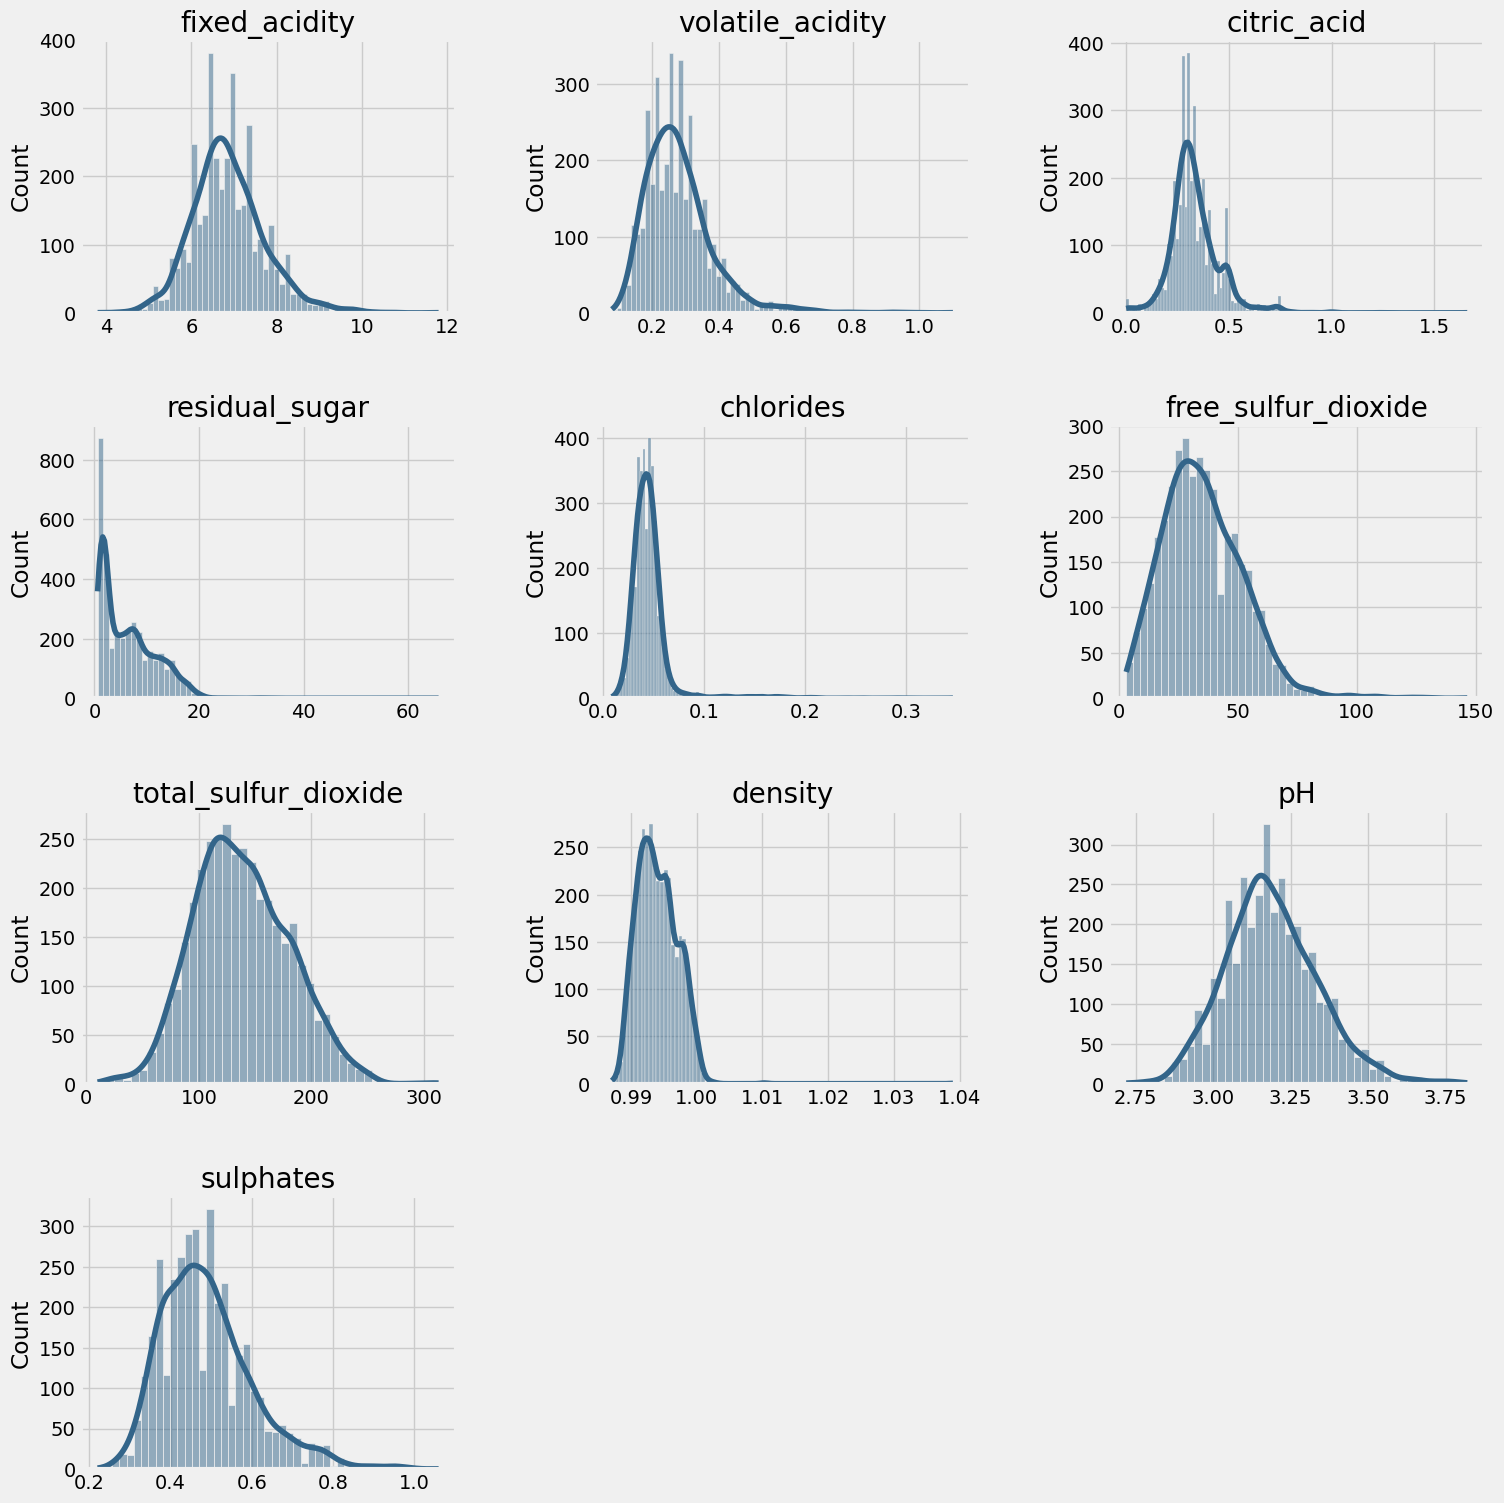

In [8]:
# Plot histograms for train data
fig, ax = plt.subplots(4, 3, figsize=(16, 16))
count = 0
for item in X_train.columns.tolist():
    sns.histplot(
        X_train[item], kde=True, ax=ax[int(count / 3)][count % 3], color="#33658A"
    ).set(title=item, xlabel="")
    count += 1
ax.flat[-2].set_visible(False)
ax.flat[-1].set_visible(False)
fig.tight_layout(pad=3)

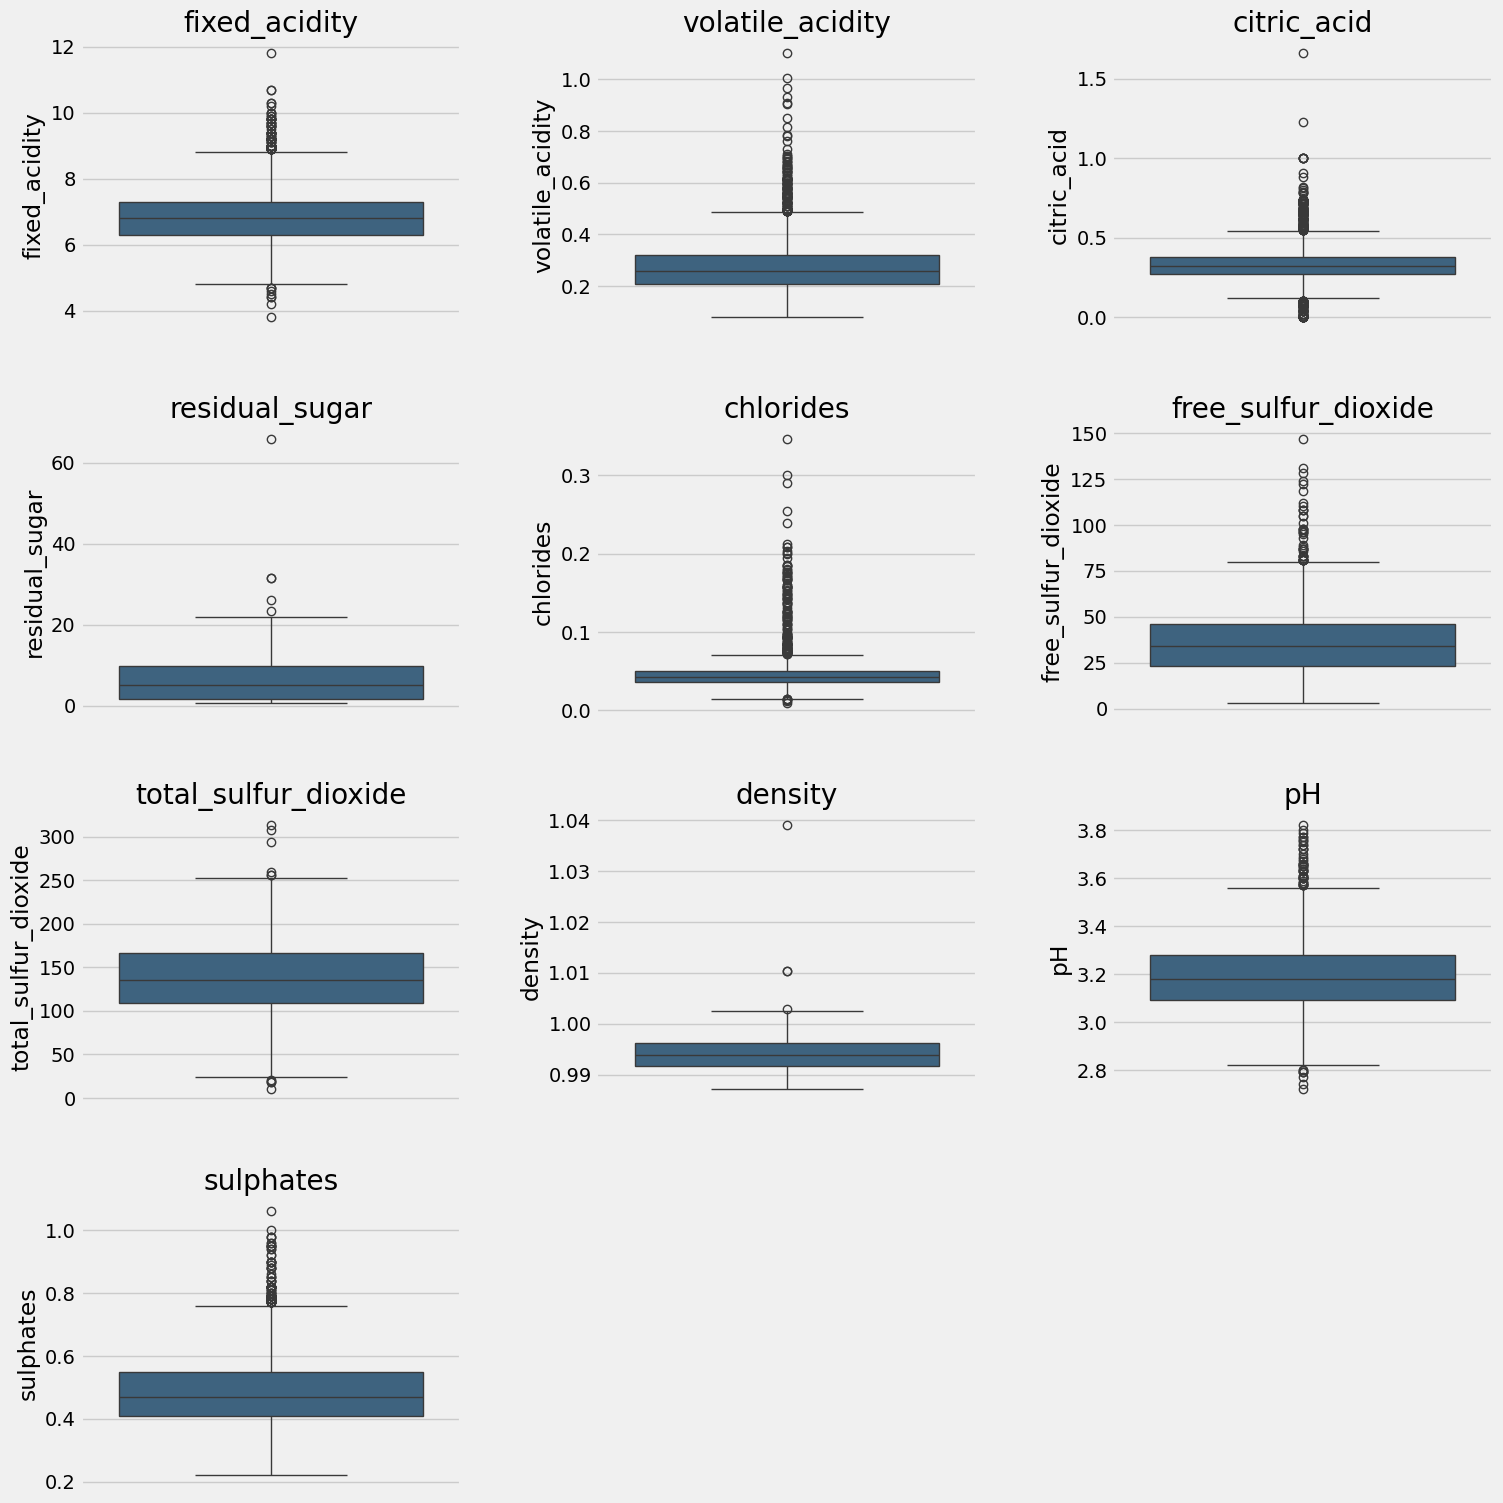

In [9]:
# Plot the training data in box plots
fig, ax = plt.subplots(4, 3, figsize=(16, 16))
count = 0
for item in X_train.columns.tolist():
    sns.boxplot(X_train[item], ax=ax[int(count / 3)][count % 3], color="#33658A"
    ).set(title=item, xlabel="")
    count += 1
ax.flat[-2].set_visible(False)
ax.flat[-1].set_visible(False)
fig.tight_layout(pad=3)

And let us look at the correlation between the features.

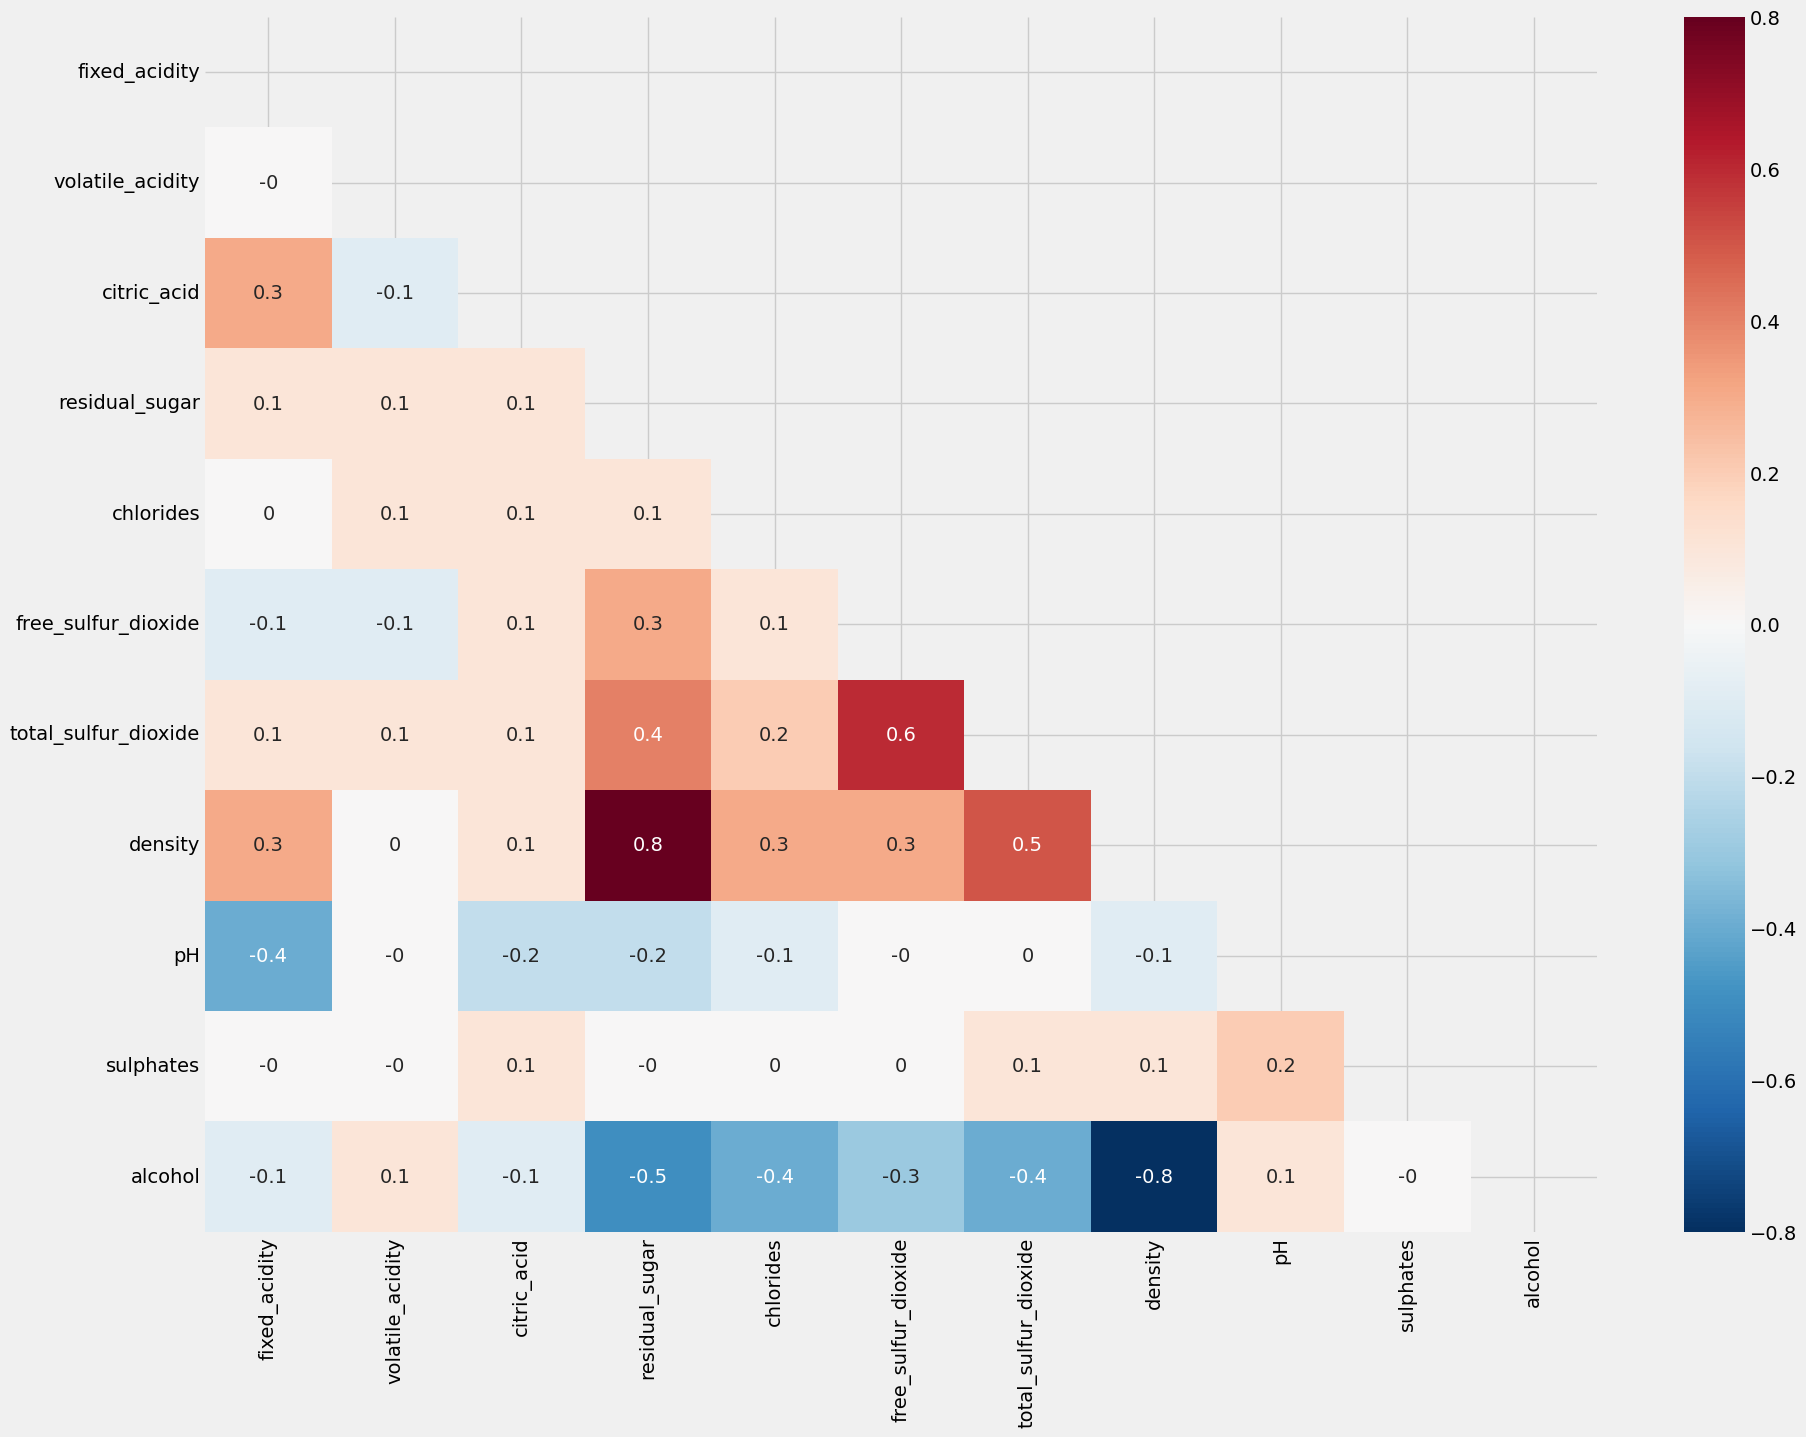

In [10]:
# Plot correlation matrix
mask = np.triu(df_train.corr())
plt.figure(figsize=(20, 15))
ax = sns.heatmap(round(df_train.corr(), 1), annot=True, mask=mask, cmap="RdBu_r")

Let's have a closer look at individual features starting with Chlorides. If you want to see more features you can of course add cells and apply the code for those you want to have a closer look at!

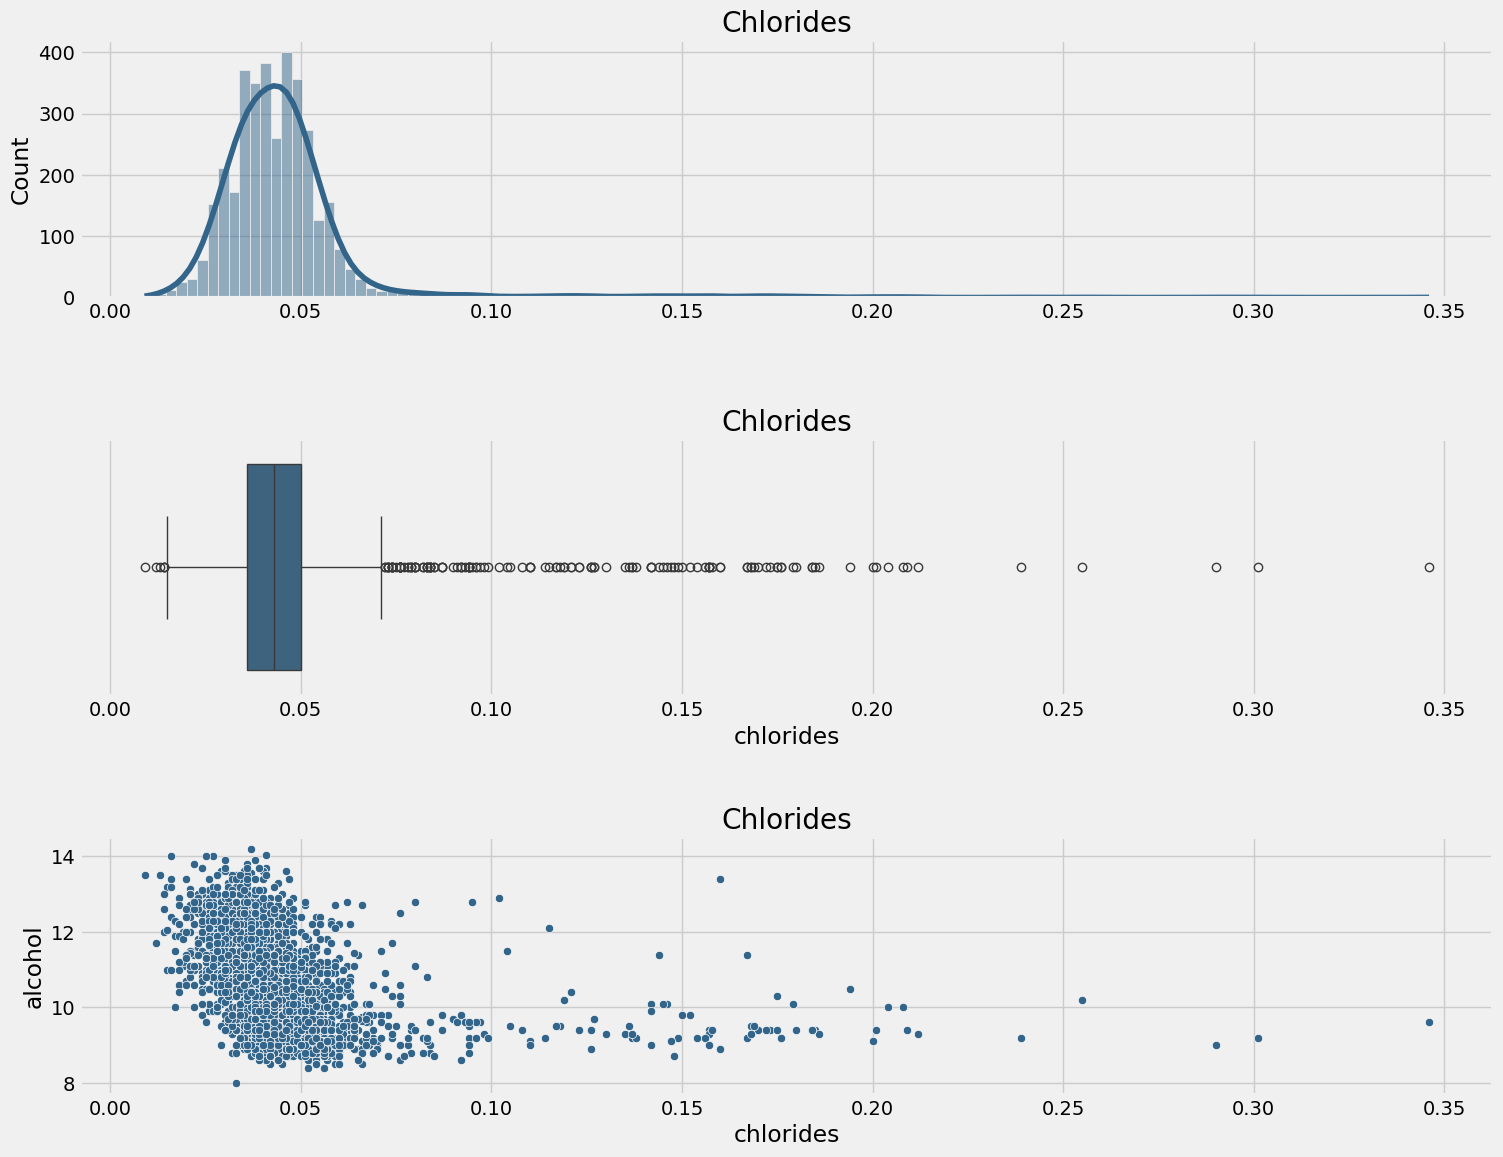

In [11]:
# Plotting one feature with histogram, box plot and scatter plot
fig, ax = plt.subplots(nrows=4, figsize=(16, 16))
count = 0
# Histogram
sns.histplot(X_train["chlorides"], kde=True, ax=ax[0], color="#33658A").set(
    title="Chlorides", xlabel=""
)
# Box plot
sns.boxplot(x=X_train["chlorides"], ax=ax[1], color="#33658A").set(title="Chlorides")
# Scatter plot
sns.scatterplot(x=X_train.chlorides, y=df_train.alcohol, ax=ax[2], color="#33658A").set(
    title="Chlorides"
)

ax.flat[-1].set_visible(False)
fig.tight_layout(pad=3)

You can see that there seem to be outliers at both ends of the distribution. But since the distribution is clearly right skewed, there are more outliers to the right.
A first step if you encounter outliers is to transform the data. Sometimes transforming the data already helps to get rid of them. There are several ways to transform the data, here are some examples:
- Log transformation
- Square root transformation
- Power transformation
- Box-Cox transformation

Let's try the log transformation for our data. As you can see on the histograms above we have several features with skewed data. We will use the transformation on all of them.

In [12]:
# Log-transform skewed features using np.log()
X_train.volatile_acidity = X_train.volatile_acidity.apply(lambda x: np.log(x))
X_train.chlorides = X_train.chlorides.apply(lambda x: np.log(x))
X_train.density = X_train.density.apply(lambda x: np.log(x))
X_train.pH = X_train.pH.apply(lambda x: np.log(x))

Now we can check if the transformation helped us to get rid of the outliers. Let's plot the chlorides column again.

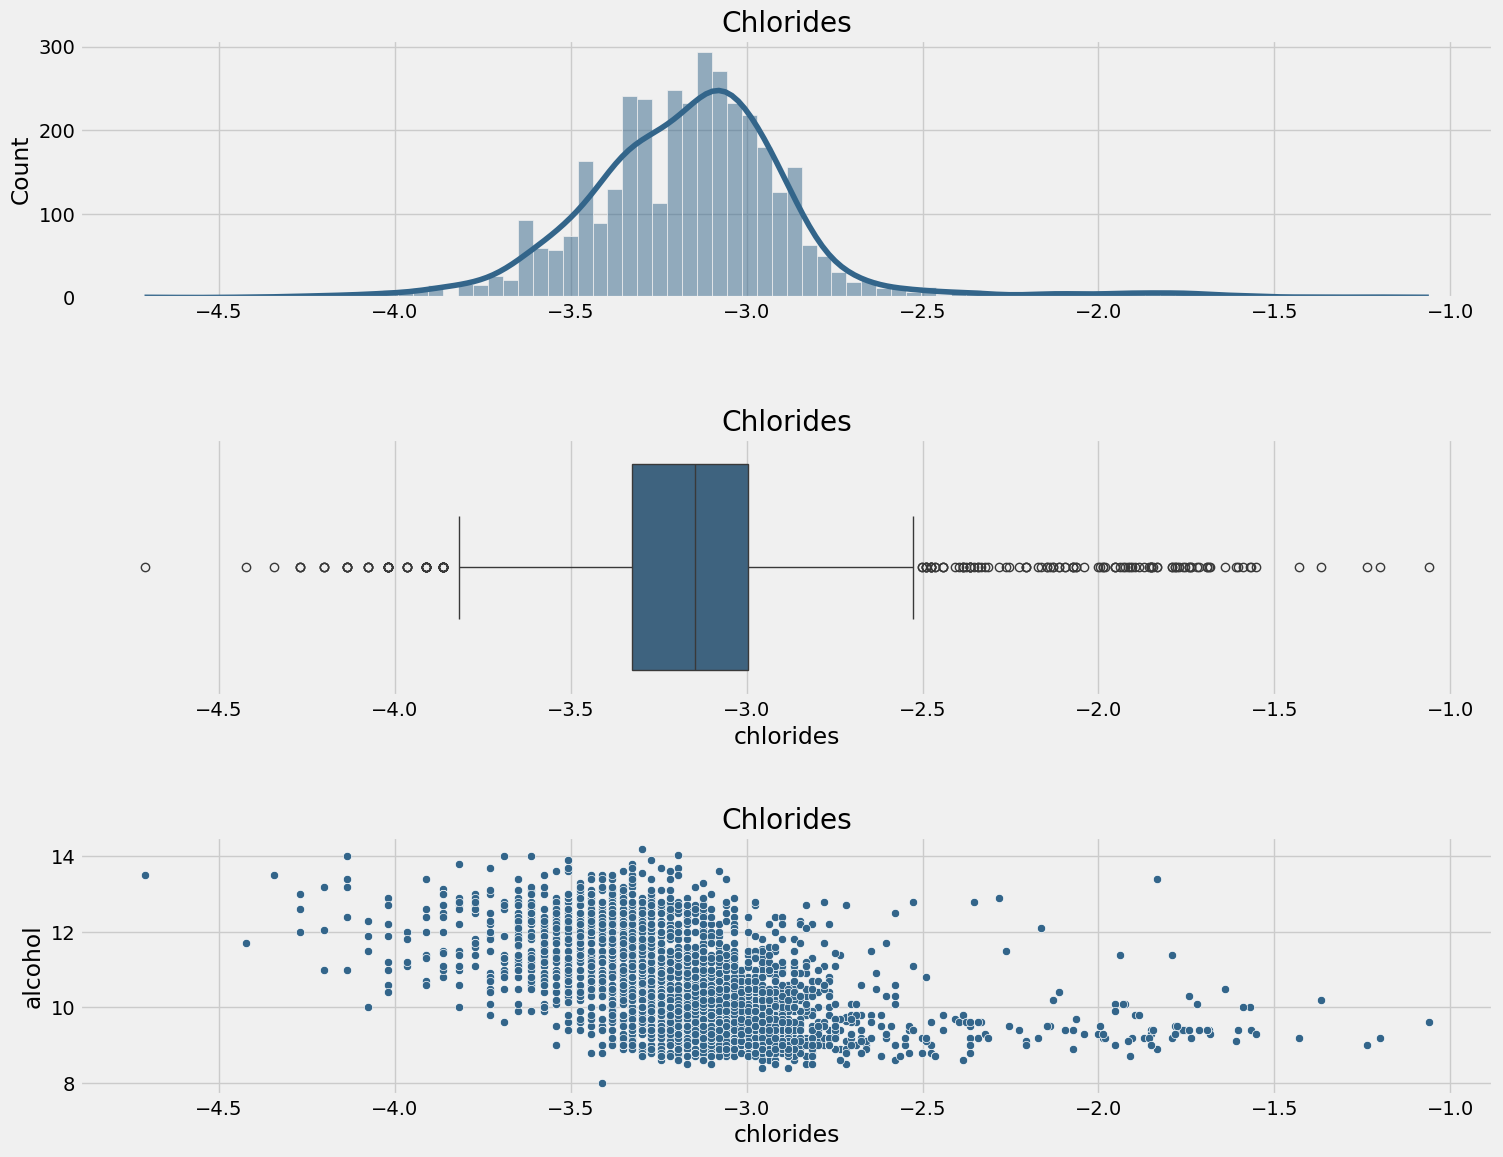

In [13]:
# Plotting one feature with histogram, box plot and scatter plot
fig, ax = plt.subplots(nrows=4, figsize=(16, 16))
count = 0
# Histogram
sns.histplot(X_train["chlorides"], kde=True, ax=ax[0], color="#33658A").set(
    title="Chlorides", xlabel=""
)
# Box plot
sns.boxplot(x=X_train["chlorides"], ax=ax[1], color="#33658A").set(title="Chlorides")
# Scatter plot
sns.scatterplot(x=X_train.chlorides, y=df_train.alcohol, ax=ax[2], color="#33658A").set(
    title="Chlorides"
)

ax.flat[-1].set_visible(False)
fig.tight_layout(pad=3)

We got rid of the skewness but there are still outliers. So let's calculate the z-score for the features after the transformation. `Scipy` provides us with an easy way to calculate the z-score for our whole dataset:

In [14]:
# Calculate z-score for whole dataset
df_zscore = zscore(df_train)
df_zscore

array([[-0.66770463, -0.28734949, -0.94253451, ..., -0.19632566,
         0.09208801, -0.00834466],
       [ 1.10380585,  0.20506195, -0.35973215, ..., -0.19632566,
        -0.9646345 , -1.22762224],
       [ 0.63140305,  0.99292025, -0.52624711, ..., -0.12946389,
        -0.52433346, -0.41477052],
       ...,
       [ 0.86760445, -0.09038491,  1.55518988, ..., -1.13239039,
         0.35626864,  0.72322189],
       [-0.66770463, -0.38583178, -0.35973215, ..., -0.12946389,
        -0.9646345 ,  0.07294051],
       [ 1.45810795, -0.09038491,  0.13981272, ...,  0.20484494,
         1.23687074, -0.08962983]], shape=(3673, 11))

When we are considering to remove outliers based on the z-score or any other threshold, we have to calculate what percentage of the data we would loose. If the proportion we were to remove is too large, we need to reconsider our approach. 

So let's calculate how much rows we would delete if we would remove the outliers with a threshold of 3 standard deviations.

In [15]:
# Calculate data loss based on 3 standard deviations
num_outlier = len(df_train[(np.abs(zscore(df_train)) > 3).any(axis=1)])
print(f"{num_outlier} rows of {len(df_train)} total rows contain outliers.")
print(f"Percentage of data loss: {num_outlier / len(df_train) * 100:.2f}%")

289 rows of 3673 total rows contain outliers.
Percentage of data loss: 7.87%


Roughly 8% of the observations in our dataframe contain one or more outliers. 8% is quite a lot, especially when you have a small dataset. Nevertheless, we will continue to create a dataframe without those observations. Therefore, we can calculate the z-score for each column and take the absolute value to query our dataframe and only keep those rows with z-scores lower than 3.

In [16]:
# Calculate z-score and query dataframe to remove rows with z-scores > 3
X_train_wo_outlier = X_train[
    (np.abs(zscore(df_train.select_dtypes(exclude="object"))) < 3).all(axis=1)
]

This way we got rid of the rows in our feature dataframe. But now we have to make sure to drop the corresponding entries in our target variable as well.
To drop the same rows in y_train we have to merge df_train_wo_outlier and y_train and afterwards split them again.

In [17]:
# Remove outliers in target variable
df_train_wo_outlier = pd.merge(
    X_train_wo_outlier, y_train, left_index=True, right_index=True
)
y_train_wo_outlier = df_train_wo_outlier["alcohol"]
X_train_wo_outlier = df_train_wo_outlier.drop("alcohol", axis=1)

That worked! We have removed the outliers from our dataframe. Now let's see how the distribution looks like.

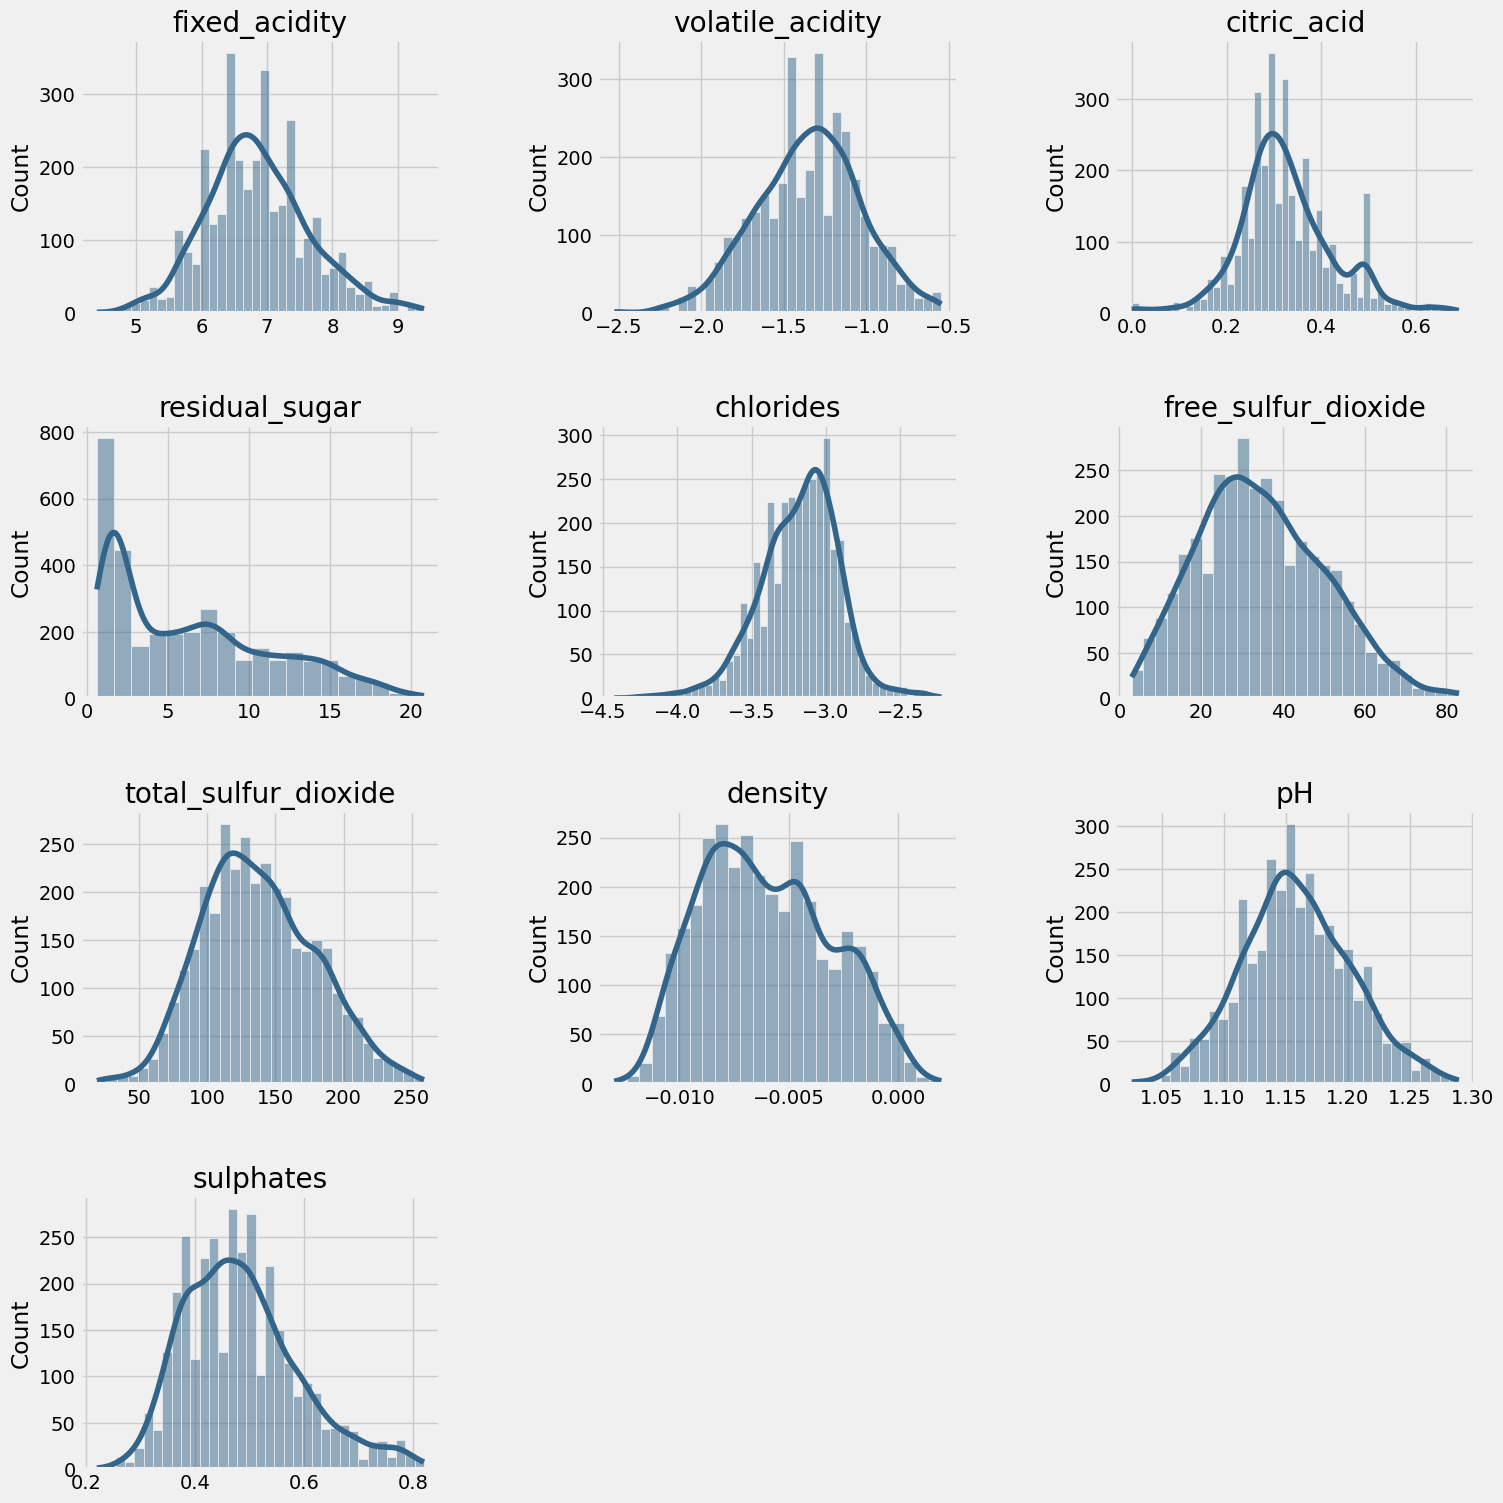

In [18]:
# Plot histograms for cleaned features
fig, ax = plt.subplots(4, 3, figsize=(16, 16))
count = 0
for item in X_train_wo_outlier.columns.tolist():
    sns.histplot(
        X_train_wo_outlier[item],
        kde=True,
        ax=ax[int(count / 3)][count % 3],
        color="#33658A",
    ).set(title=item, xlabel="")
    count += 1
ax.flat[-1].set_visible(False)
ax.flat[-2].set_visible(False)
fig.tight_layout(pad=3)

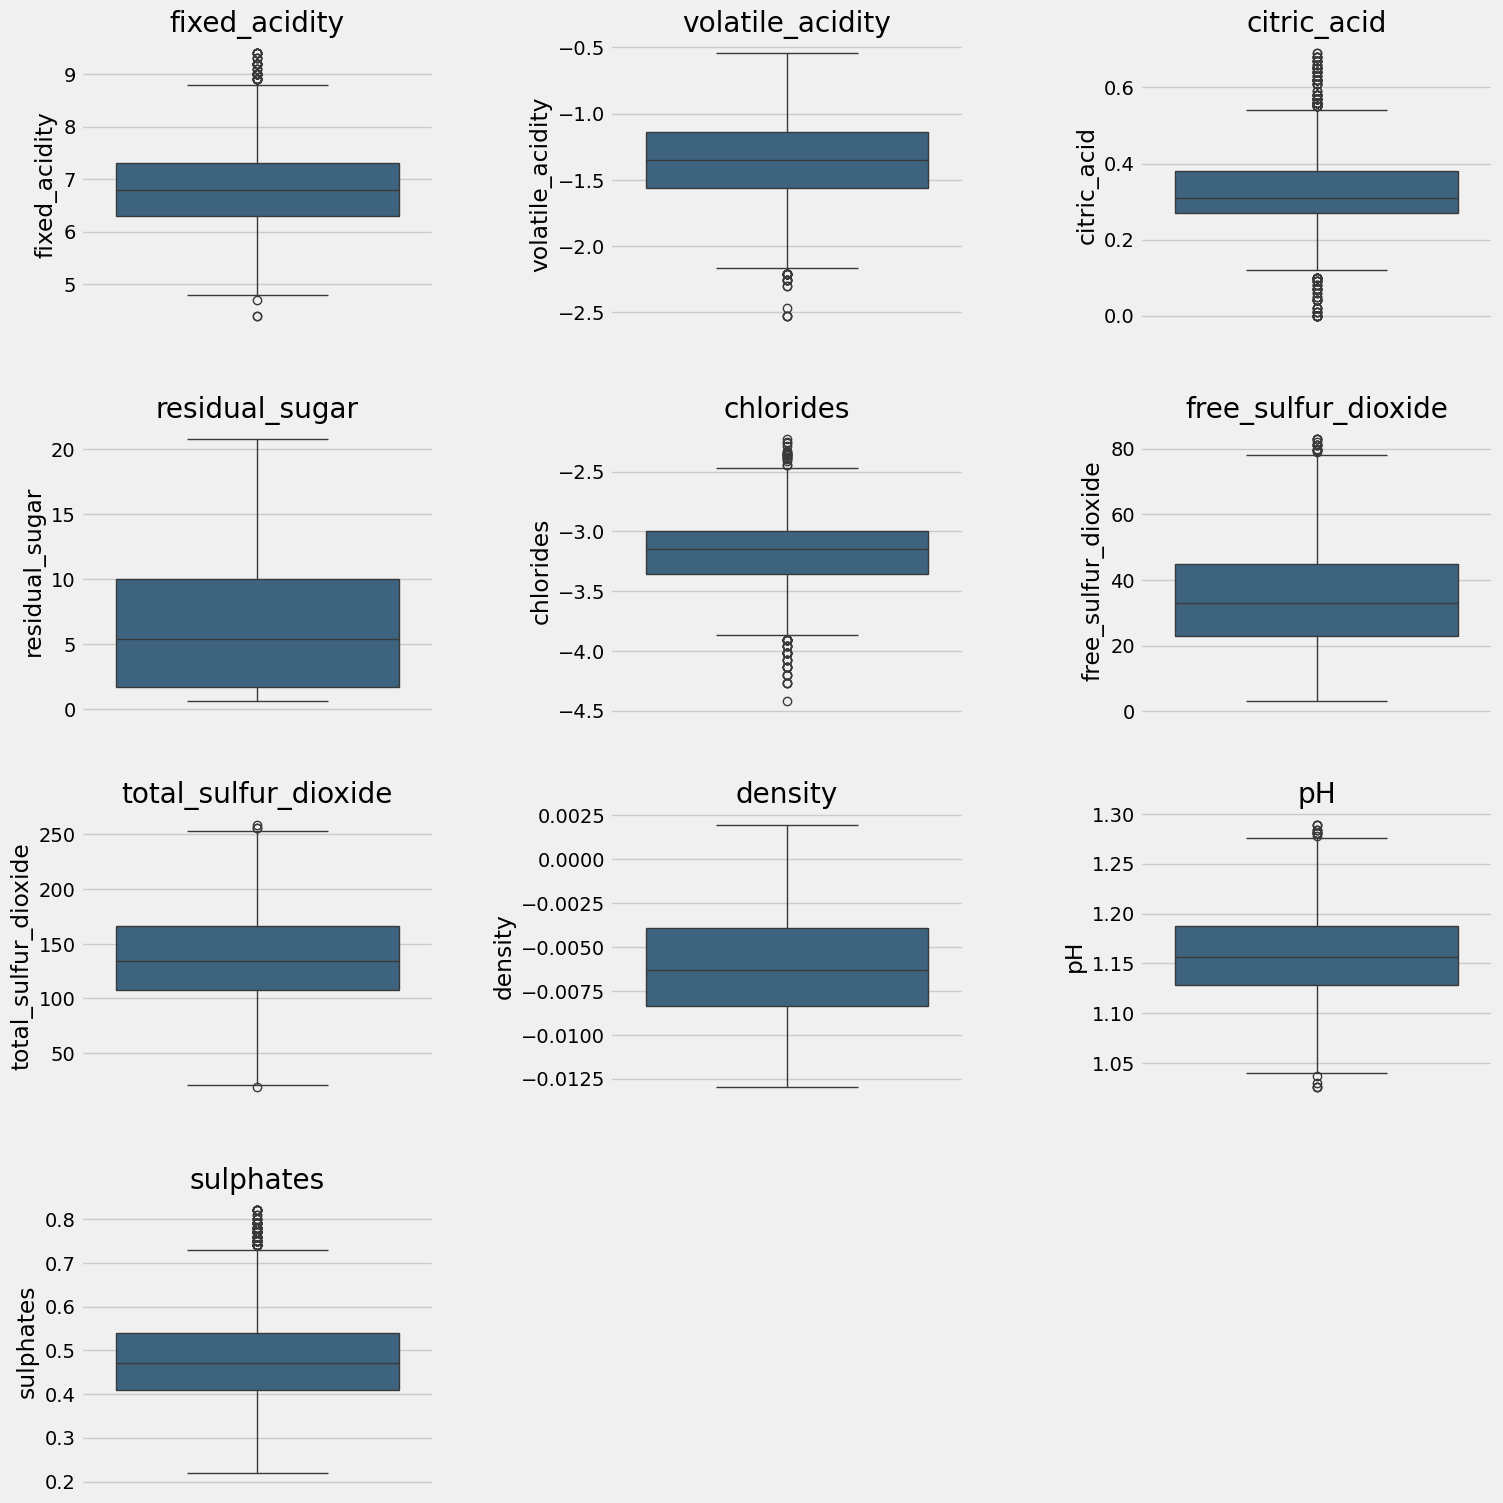

In [19]:
# And again you can plot the box plots using the code from above
fig, ax = plt.subplots(4,3, figsize=(16,16))
count = 0
for item in X_train_wo_outlier.columns.tolist():
    sns.boxplot(
        X_train_wo_outlier[item],
        ax=ax[int(count / 3)][count % 3],
        color="#33658A",
    ).set(title=item, xlabel="")
    count += 1
ax.flat[-1].set_visible(False)
ax.flat[-2].set_visible(False)
fig.tight_layout(pad=3)

Did the correlation matrix also change? Let's have a look at the correlation matrix.

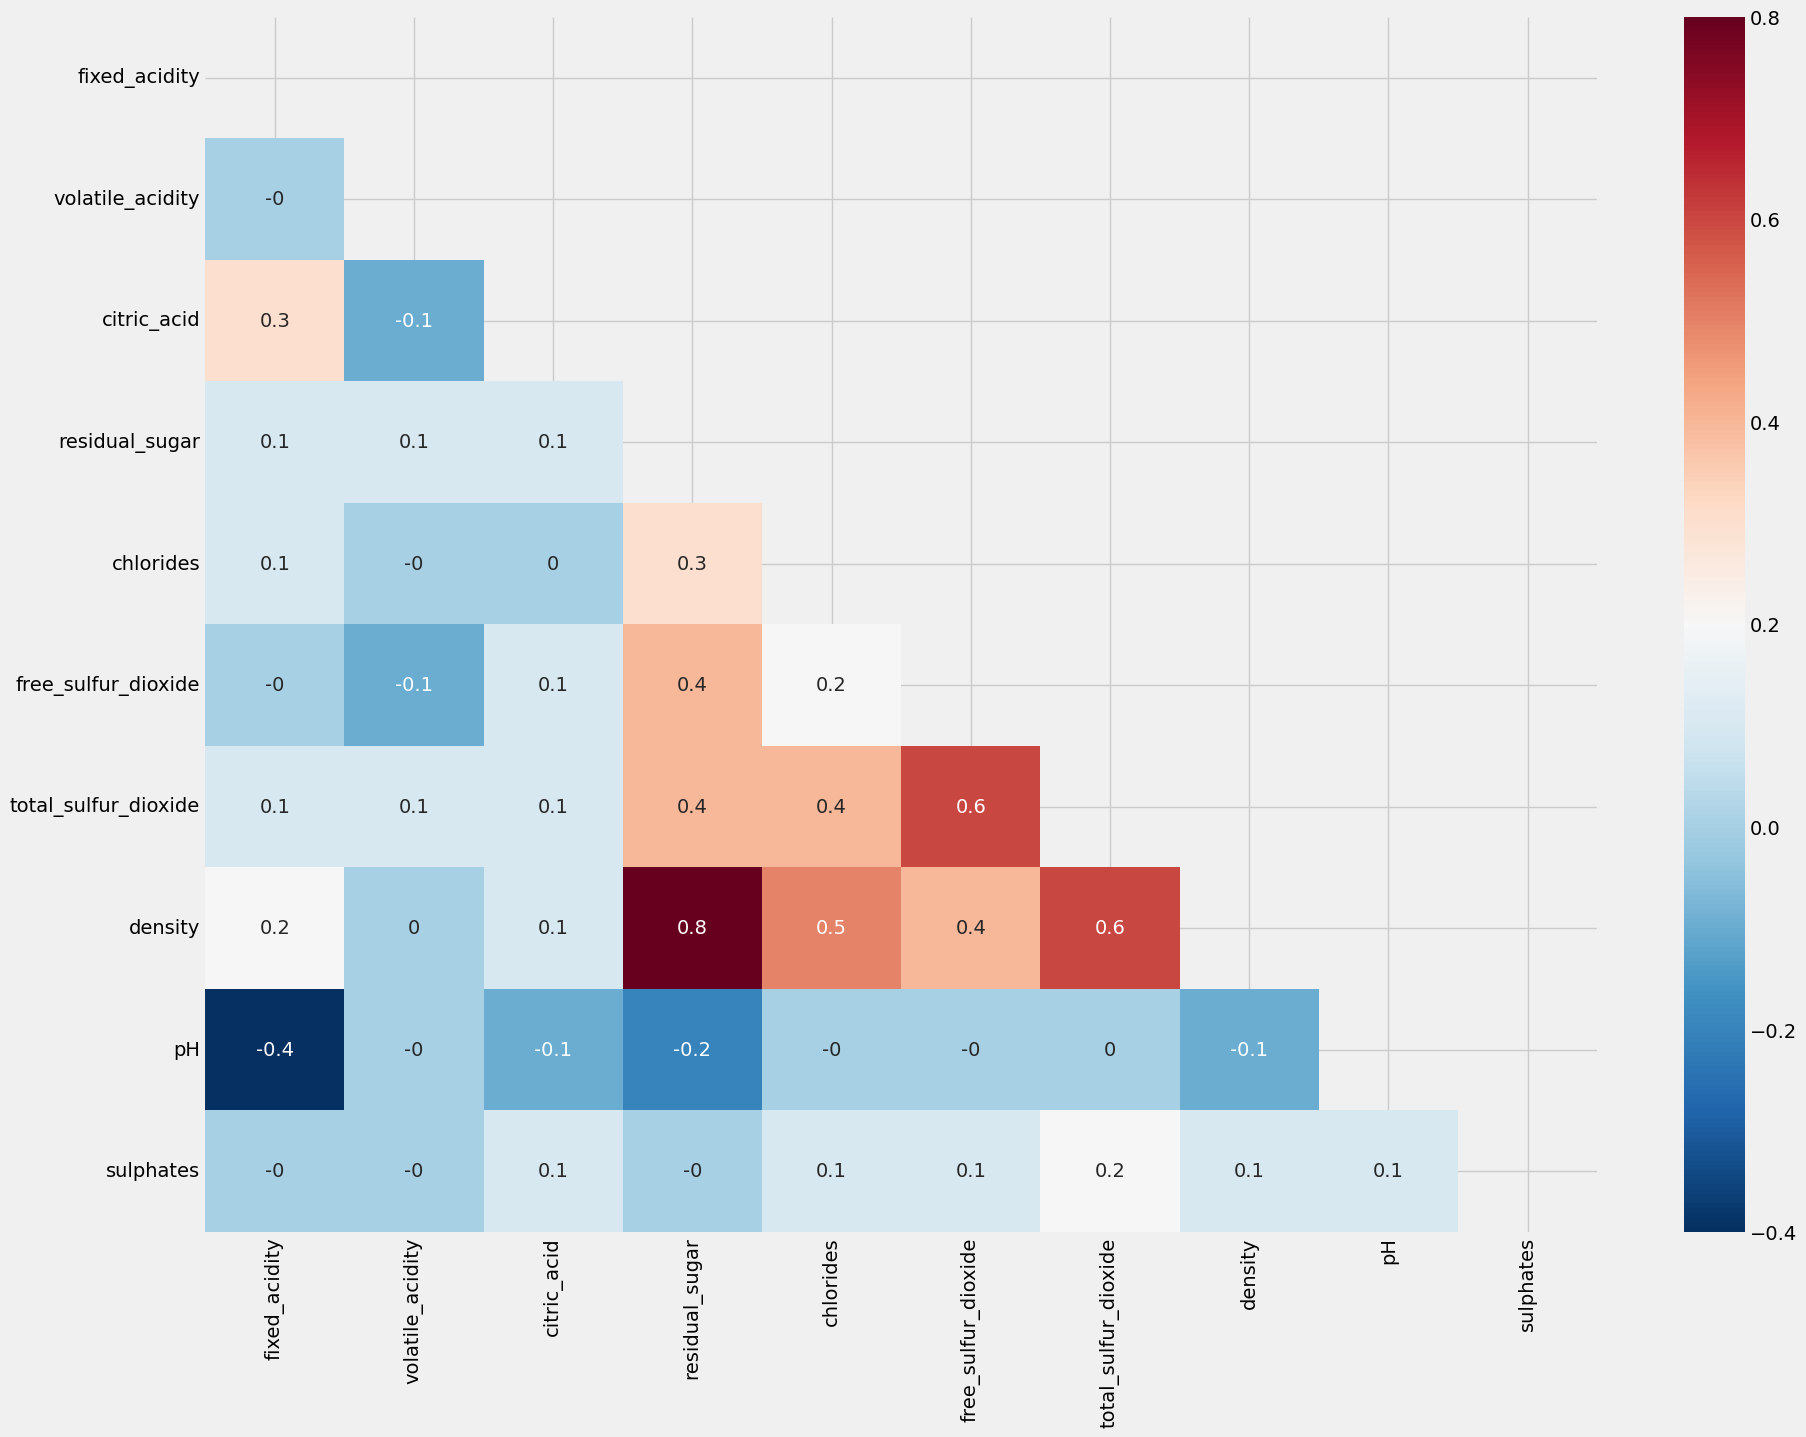

In [20]:
# Plot correlation matrix for cleaned data
mask = np.triu(X_train_wo_outlier.corr())
plt.figure(figsize=(20, 15))
ax = sns.heatmap(
    round(X_train_wo_outlier.corr(), 1), annot=True, mask=mask, cmap="RdBu_r"
)

## Influence of Outlier Removal on Model Performance



Now let's compare two models. The first one is a simple linear regression model trained on the data without the removal of outliers. The second one is a linear regression model trained on the data with the removal of outliers. Before we can use the test set for evaluating our models we need to transform it the same way the training set was transformed.

In [21]:
# To-Do: Apply log transformation from train set to test set as X_test Your Code! np.log(x))
X_test.volatile_acidity = X_test.volatile_acidity.apply(lambda x: np.log(x))
X_test.chlorides = X_test.chlorides.apply(lambda x: np.log(x))
X_test.density = X_test.density.apply(lambda x: np.log(x))
X_test.pH = X_test.pH.apply(lambda x: np.log(x))

### Model with Outliers

For the model which is trained on the data with outliers we will use `X_train` and `y_train`.

In [22]:
# Instantiate our model
lin_reg = LinearRegression()

# Fit the model using our train data
lin_reg.fit(X_train, y_train)

# Make predictions on the train data  and on the test data
y_pred_train = lin_reg.predict(X_train)
y_pred = lin_reg.predict(X_test)

### Model without Outliers

This model will be trained on our clean data `X_train_wo_outlier` and `y_train_wo_outlier`.

In [23]:
# To-Do:
# Instantiate the model
lin_reg = LinearRegression()

# Fit the model using our train data  with outlier removed and your target variable
lin_reg.fit(X_train_wo_outlier, y_train_wo_outlier)

# Make predictions on the train data and on the test data
y_pred_train_wo_outlier = lin_reg.predict(X_train_wo_outlier)
y_pred_test_wo_outlier = lin_reg.predict(X_test)

### Model Comparison

Let's see if our efforts have paid off:

In [24]:
print("With outliers:")
print("R-squared train: ", round(r2_score(y_train, y_pred_train), 3))
print("R-squared test: ", round(r2_score(y_test, y_pred), 3))
print("RMSE train: ", round(root_mean_squared_error(y_train, y_pred_train), 3))
print("RMSE test: ", round(root_mean_squared_error(y_test, y_pred), 3))
print("-----------------------------------")
print("Without outliers:")
print(
    "R-squared train: ", round(r2_score(y_train_wo_outlier, y_pred_train_wo_outlier), 3)
)
print("R-squared test: ", round(r2_score(y_test, y_pred_test_wo_outlier), 3))
print(
    "RMSE train: ",
    round(root_mean_squared_error(y_train_wo_outlier, y_pred_train_wo_outlier), 3),
)
print("RMSE test: ", round(root_mean_squared_error(y_test, y_pred_test_wo_outlier), 3))

With outliers:
R-squared train:  0.86
R-squared test:  0.906
RMSE train:  0.46
RMSE test:  0.377
-----------------------------------
Without outliers:
R-squared train:  0.919
R-squared test:  0.911
RMSE train:  0.35
RMSE test:  0.366


Apparently, we did a good job! The model trained with the clean data outperforms the other model in both metrics.

## Final Remark



Handle this notebook with care! We showed you how you can remove outliers using the z-score method. But we didn't dive into the business question if it makes sense to remove all the outliers from the dataset or if they are legitimate special cases of the feature. You want to loose as little data as possible. Because of course if you remove data from the dataset the model will also not be able to learn something about those cases. So, you should be careful and remove them only if it makes sense both from a mathematical/statistical and a business point of view.

In some cases you can also remove outlier from your target variable, but you have to be sure that it makes sense in business perspective and you have to track the variable in production to be sure that the outlier will not appear often or if the distribution of the data changes. Because if you model doesn't work for all customers you may loose them.

Here is also a good article on when [To Drop or Not to Drop](https://www.theanalysisfactor.com/outliers-to-drop-or-not-to-drop/)!

# Zusammenfassung der wichtigsten Erkenntnisse

## 1. Die wichtigsten Ergebnisse

In diesem Notebook haben wir gesehen, dass Ausreißer oft sehr auffällig sind, aber nicht automatisch Fehler sein müssen. Die Kombination aus grafischer Prüfung, Log-Transformation und Z-Score hat gezeigt, dass extreme Werte oft durch starke Schiefe oder einzelne ungewöhnliche Beobachtungen entstehen. Nach der Bereinigung der Daten war die Verteilung deutlich besser interpretierbar.

Der zentrale Vergleich zwischen den beiden Modellen zeigt: Das Regressionsmodell, das auf den bereinigten Daten trainiert wurde, war in der Gesamtbewertung besser. Die Genauigkeit verbesserte sich vor allem bei den Modellmetriken `RMSE` und `R²`. Das bedeutet: Wenn die Ausreißer sinnvoll entfernt werden, kann das Modell besser lernen und auf neue Daten oft zuverlässiger reagieren.

## 2. Zentrale fachliche Erkenntnisse

- Ausreißer sind Werte, die deutlich außerhalb des typischen Bereichs liegen.
- Ein Z-Score beschreibt, wie weit ein Wert vom Mittelwert entfernt ist, gemessen in Standardabweichungen.
- Eine Log-Transformation hilft oft, wenn die Verteilung sehr schief ist und einige Werte stark nach rechts oder links abweichen.
- Wenn wir Ausreißer aus dem Trainingssatz entfernen, müssen wir den Testsatz unverändert lassen. Sonst erhalten wir ein zu optimistisches Ergebnis.
- Regressionsmodelle reagieren empfindlich auf extreme Werte, weil sie den Zusammenhang zwischen Merkmalen und Zielwert auf einer Geraden modellieren.
- `RMSE` zeigt den durchschnittlichen Fehler in derselben Einheit wie die Zielvariable. Ein kleinerer Wert ist besser.
- `R²` zeigt, wie viel der Variation in der Zielgröße durch das Modell erklärt wird. Höhere Werte bedeuten im Allgemeinen eine bessere Passung.

## 3. Interpretation der Grafiken und Ausgaben

Die Histogramme und Boxplots zeigten zunächst starke Schiefe und auffällige Randwerte. Das ist typisch für Datensätze mit wenigen extremen Beobachtungen. Diese Grafiken helfen dabei, ein Gefühl für die Daten zu bekommen, bevor man entscheidet, ob man die Werte verändert oder entfernt.

Die Korrelationstabelle zeigte außerdem, dass einzelne Merkmale stärker miteinander zusammenhängen. Das ist wichtig, weil extreme Werte in solchen Merkmalen ein Modell besonders beeinflussen können. Wenn ein einzelner sehr hoher Wert in einer wichtigen Variable auftaucht, kann die Gerade des Regressionsmodells stark verschoben werden.

Die Berechnung des Z-Scores zeigte, dass ein nicht geringer Teil der Datenpunkte als extrem galt. Das war ein wichtiger Moment: Gerade bei kleinen Datensätzen kann das Entfernen von mehr als 5 bis 10 Prozent der Beobachtungen große Auswirkungen haben. Deshalb ist nicht jede extreme Zahl automatisch ein Fehler.

## 4. Unterschied zwischen den verwendeten Methoden

Der Unterschied zwischen der grafischen Analyse und der statistischen Methode ist wichtig:

- Grafische Methoden wie Histogramme und Boxplots helfen beim Verständnis und beim ersten Eindruck.
- Der Z-Score liefert eine klare, numerische Regel: Werte mit einem sehr hohen Betrag gelten als auffällig.
- Die Log-Transformation ist keine Methode zum Entfernen von Ausreißern selbst, sondern eine Technik, um die Daten besser beherrschbar zu machen.
- Das Regressionsmodell ist dann der eigentliche Prüfstein: Es zeigt, ob die Behandlung der Ausreißer auch in der Praxis etwas bringt.

In diesem Notebook war die Kombination aus Beobachtung und statistischer Prüfung besonders sinnvoll, weil sie nicht nur „Werte löschen“, sondern auch erklären, warum die Daten so aussehen.

## 5. Typische Fehlerquellen und Grenzen

Eine häufige Fehlerquelle ist, einfach alle extremen Werte zu entfernen, ohne zu prüfen, ob sie wirklich fehlerhaft sind. In manchen Fällen sind sie echte, wichtige Sonderfälle. Wenn man zu viel entfernt, verliert man Information und das Modell lernt weniger über die reale Vielfalt der Daten.

Eine weitere Grenze ist, dass der Z-Score nur für bestimmte Verteilungen gut funktioniert. Wenn die Daten deutlich nicht normal verteilt sind, kann die Regel zu grob oder zu streng sein. Das gilt besonders bei kleinen Datensätzen oder bei stark verzerrten Merkmalen.

Auch die Log-Transformation hilft nur bedingt. Sie macht manche Verteilungen besser, aber nicht alle. Man muss deshalb immer die Daten und die Zielfrage anschauen und nicht nur eine Technik blind anwenden.

## 6. Praktische Schlussfolgerung

Die wichtigste praktische Lehre ist: Ausreißer sollten nicht automatisch gelöscht werden. Man sollte sie zuerst verstehen, dann gezielt prüfen und nur dann entfernen, wenn das mathematisch und fachlich sinnvoll ist. Gerade bei Daten aus echten Geschäftsprozessen gilt: Ein Ausreißer kann ein echter Sonderfall sein, nicht nur ein Fehler.

Wenn die Daten sauber behandelt werden, kann ein Modell robuster und verständlicher werden. Das ist besonders wichtig, wenn wir mit Vorhersagen Entscheidungen treffen, zum Beispiel bei Preisen, Qualitätsbewertungen oder Kundenverhalten. In der Praxis heißt das: beobachten, bewerten, begründen und nur dann verändern.

Damit ist das zentrale Ziel dieses Notebooks erreicht: Wir haben verstanden, wie man Ausreißer erkennt, wie man sie mit einfachen Methoden prüft und wie man ihre Wirkung auf ein Modell sauber bewertet.
